# **BÀI TẬP 4 - THỐNG KÊ MÁY TÍNH VÀ ỨNG DỤNG**

---

### **Thông tin sinh viên**
- **MSSV:** 22127117

- **Họ và tên:** Lý Liên Hoa

---

#### **Thư viện**

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression, BayesianRidge
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [2]:
np.random.seed(42)

----

## **Câu 1.**

Dữ liệu của 2 đại lượng $X, Y$ được cho trong bảng sau

| $ X $ | $1.11$ | $0.00$ | $0.47$ | $0.23$ | $0.14$ | $0.29$ | $0.53$ | $0.61$ | $0.83$ | $0.65$ | $1.05$ | $0.31$ |
|:-----:|:------:|:------:|:------:|:------:|:------:|:------:|:------:|:------:|:------:|:------:|:------:|:------:|
| $ Y $ | $2.38$ | $1.03$ | $1.00$ | $0.90$ | $0.93$ | $0.90$ | $1.06$ | $1.16$ | $1.57$ | $1.22$ | $2.18$ | $0.91$ |

| $ X $ | $1.35$ | $0.04$ | $1.03$ | $0.64$ | $0.86$ | $0.22$ | $0.30$ | $1.23$ | $1.49$ | $0.48$ | $1.07$ | $1.35$ |
|:-----:|:------:|:------:|:------:|:------:|:------:|:------:|:------:|:------:|:------:|:------:|:------:|:------:|
| $ Y $ | $3.32$ | $0.99$ | $2.12$ | $1.21$ | $1.65$ | $0.90$ | $0.91$ | $2.82$ | $3.98$ | $1.01$ | $2.25$ | $3.32$ |

*Phần I.* Biết rằng $X \sim \mathcal{U}(0, \theta)$, ta có thể dùng các ước lượng sau cho $\theta$
$$
T_1 = 2\bar{X}, \quad T_2 = 2\hat{m}, \quad T_3 = 2\sqrt{3}\,S, \quad T_4 = max\{X_1, X_2, ..., X_n\}
$$
với $\bar{X}, \hat{m}, S, \max$ lần lượt là trung bình, trung vị, độ lệch chuẩn và giá trị lớn nhất của mẫu.

$\quad$ a. Tính các giá trị ước lượng $T_1, T_2, T_3, T_4$ cho $\theta$ từ mẫu dữ liệu đã cho.

$\quad$ b. Dùng kĩ thuật bootstrapping, so sánh sai số chuẩn của các ước lượng trên.

$\quad$ c. Giả sử ta có thêm thông tin là $\theta = 1 + e, e \sim Exponential(1)$ và $\theta \le 2$. Dùng kĩ thuật suy diễn Bayes để ước lượng $\theta$. So sánh sai số của ước lượng này với các ước lượng trên.

<br>


*Phần II.*

$\quad$ d. Tính hệ số tương quan mẫu giữa $X$ và $Y$.

$\quad$ e. Kiểm định giả thuyết "$X$ và $Y$ có tương quan" bằng kiểm định hệ số tương quan trong `scipy` (https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html )

$\quad$ f. Dùng kĩ thuật lấy mẫu lại hoán vị, kiểm định giả thuyết "$X$ và $Y$ có tương quan" và so sánh kết quả với Câu (e)

<br>

*Phầm III.* Xét mô hình hồi qui tuyến tính
$$
Y = a + bX + cX^2  + \epsilon
$$
với $a, b, c$ là các hệ số và $\epsilon$ là lỗi

$\quad$ g. Ước lượng các hệ số hồi qui $a, b, c$

$\quad$ h. Dùng kĩ thuật bootstrapping, xây dựng khoảng tin cậy $95\%$ cho $a, b, c$

$\quad$ i. Giả sử ta dùng mô hình hồi qui trên để dự đoán giá trị cho $Y$ là $y_0$ tại $x_0 = 0.5$. Dùng kĩ thuật bootstrapping, ước lượng sai số dự đoán và xây dựng khoảng tin cậy $95\%$ cho $y_0$

---

### **PHẦN I.**

#### $\quad$ **a. Tính các giá trị ước lượng $T_1, T_2, T_3, T_4$ cho $\theta$ từ mẫu dữ liệu đã cho.**

- $T_1:$
$$
T_1 = 2 \bar{X} = 2 \cdot \frac{1}{n} \cdot \sum_{i = 1}^{n} x_i
$$

- $T_2:$
$$
T_2 = 2\hat{m},
$$
$\quad\quad\quad$ Với $n = 24$, trung vị $\hat{m}$ được tính bằng trung bình của phần tử thứ $(\frac{n}{2})$ và $(\frac{n}{2} + 1)$ của mẫu sau khi đã sắp xếp.

- $T_3:$
$$
T_3 = 2\sqrt{3}\,S = 2\sqrt{3}\, \sqrt{\frac{1}{n - 1} \sum_{i=1}^{n}(X_i - \bar{X})^2}
$$

- $T_4:$
$$
T_4 = \max\{X_1, X_2, ..., X_n\}
$$

In [3]:
X = np.array([1.11, 0.00, 0.47, 0.23, 0.14, 0.29, 0.53, 0.61, 0.83, 0.65, 1.05, 0.31, 1.35, 0.04, 1.03, 0.64, 0.86, 0.22, 0.30, 1.23, 1.49, 0.48, 1.07, 1.35])
Y = np.array([2.38, 1.03, 1.00, 0.90, 0.93, 0.90, 1.06, 1.16, 1.57, 1.22, 2.18, 0.91, 3.32, 0.99, 2.12, 1.21, 1.65, 0.90, 0.91, 2.82, 3.98, 1.01, 2.25, 3.32])

In [4]:
mean_X  = np.mean(X)
median_X = np.median(X)
std_X = np.std(X)
max_X = np.max(X)

In [5]:
T_1 = 2 * mean_X
T_2 = 2 * median_X
T_3 = 2 * np.sqrt(3) * std_X
T_4 = max_X

In [6]:
print("a. Các ước lượng cho theta:")
print(f"T_1 = {T_1}")
print(f"T_2 = {T_2}")
print(f"T_3 = {T_3}")
print(f"T_4 = {T_4}")

a. Các ước lượng cho theta:
T_1 = 1.3566666666666667
T_2 = 1.25
T_3 = 1.521961453738782
T_4 = 1.49


#### $\quad$ **b. Dùng kĩ thuật bootstrapping, so sánh sai số chuẩn của các ước lượng trên.**

In [7]:
B = 10000
n = len(X)

T_1_bootstrap = np.zeros(B) 
T_2_bootstrap = np.zeros(B) 
T_3_bootstrap = np.zeros(B) 
T_4_bootstrap = np.zeros(B) 

for i in range(B):
    samples = np.random.choice(X, size=n, replace=True)

    mean_bt = np.mean(samples)
    median_bt = np.median(samples)
    std_bt = np.std(samples)
    max_bt = np.max(samples)

    T_1_bootstrap[i] = 2 * mean_bt
    T_2_bootstrap[i] = 2 * median_bt
    T_3_bootstrap[i] = 2 * np.sqrt(3) * std_bt
    T_4_bootstrap[i] = max_bt

se_T1 = np.std(T_1_bootstrap, ddof=1)
se_T2 = np.std(T_2_bootstrap, ddof=1)
se_T3 = np.std(T_3_bootstrap, ddof=1)
se_T4 = np.std(T_4_bootstrap, ddof=1)

In [8]:
print("Sai số của các ước lượng: ")
print(f"- T1: {se_T1}")
print(f"- T2: {se_T2}")
print(f"- T3: {se_T3}")
print(f"- T4: {se_T4}")

Sai số của các ước lượng: 
- T1: 0.17937318479574577
- T2: 0.30406147871488726
- T3: 0.14698107936744453
- T4: 0.0819435388139622


#### $\quad$ **c. Giả sử ta có thêm thông tin là $\theta = 1 + e, e \sim Exponential(1)$ và $\theta \le 2$. Dùng kĩ thuật suy diễn Bayes để ước lượng $\theta$. So sánh sai số của ước lượng này với các ước lượng trên.**

Theo đề, $X_1, X_2, ..., X_n \; (n = 24)$ được lấy từ phân phối đồng đều: $X \sim \mathcal{U}(0, \theta)$ có hàm mật độ:

$$
f(x) = 
\begin{cases}
\frac{1}{\theta} &  0 \le x \le \theta \\
0 & \text{khác}
\end{cases}
$$

Với bộ dữ liệu $X = (X_1, X_2, ..., X_n)$, ta có hàm hợp lý như sau:
- Nếu tất cả các giá trị $X_i$ thõa $0 \le X_i \le \theta$, tức $\max\{X_1, X_2, ..., X_n\} \le \theta$, thì ta có:
$$
L(\theta | X) = \frac{1}{\theta^n}
$$

- Tuy nhiên, nếu tồn tại $X_i > \theta$ thì hàm hợp lý bằng 0

$\quad$ Trong dữ liệu, ta có $\max\{X\} = 1.49$ nếu tồn tại $1.49 > \theta$ thì hàm hợp lý bằng 0

Theo đề ta có thêm thông tin $\theta = 1 + e, e \sim Exponential(1)$ và $\theta \le 2$

Do $e$ có hàm mật độ:
$$
p(e) = \mathcal{e}^{-e} \quad \text{với } e \ge 0
$$

Thế nên, với $e = \theta - 1$ thì:
$$
p(\theta) = e^{-(\theta - 1)}, \quad \text{với } \theta \ge 1
$$

ngược lại, khi $\theta < 1$ thì $p(\theta) = 0$

Để có hàm mật độ tiên nghiệm chuẩn hóa trên đoạn $[1, 2]$, ta phải chia cho hằng số chuẩn hóa, với hằng số chuẩn hóa được tính như sau:
$$
P(x) = \int_{1}^{2} e^{-(\theta - 1)} d\theta = \int_{0}^{1} e^{-u} du = 1 - e^{-1}
$$

Do đó, hàm mật độ tiên nghiệm sau khi chuẩn hóa:
$$
p(\theta) = 
\begin{cases}
\frac{e^{-(\theta - 1)}}{1 - e^{-1}} & 1 \le \theta \le 2 \\
0 & \text{khác}
\end{cases}
$$

Theo định lý Bayes, phân phối hậu nghiệm của $\theta$ cho tập dữ liệu $X$ được cho bởi:
$$
p(\theta | x) = \frac{L(\theta | x) \; p(\theta)}{P(x)}
$$

Ta có:

- $L(\theta | x) = \frac{1}{\theta^n}$ nếu $\theta \geq \max\{x\} = 1.49$ và bằng $0$ nếu $\theta < \max\{X\}$

- $p(\theta) = \frac{e^{-(\theta - 1)}}{1 - e^{-1}}$ nếu $1 \le \theta \le 2$


Do đó nếu $\max\{X\} \le \theta \le 2$ thì ta có phân phối hậu nghiệm như sau:
$$
p(\theta | x) \propto \frac{e^{-(\theta - 1)}}{\theta^n}
$$

Nếu nằm ngoài khoảng trên thì: $p(\theta | x) = 0$

Ta có kỳ vọng của phân phối hậu nghiệm:
$$
E(\theta | x) = \frac{\int_{1.49}^{2} \frac{\theta \, e^{-(\theta - 1)}}{\theta^n} \, d\theta}{\int_{1.49}^{2} \frac{e^{-(\theta - 1)}}{\theta^n} \, d\theta}
$$

In [9]:
def likelihood(theta, n, max_x):
    if theta >= max_x:
        return 1 / theta**n
    else:
        return 0
    
def prior(theta):
    if 1 <= theta <= 2:
        return (np.exp(-(theta - 1))) / (1 - np.exp(-1))
    else:
        return 0
    
def unnorm(theta, n, max_x):
    return likelihood(theta, n, max_x) * prior(theta)

In [10]:
theta_grid = np.linspace(max_X, 2, 10000)
f_theta = np.array([unnorm(theta, n, max_X) for theta in theta_grid])

C = np.trapz(f_theta, theta_grid)
posterior = f_theta / C

posterior_mean = np.trapz(theta_grid * posterior, theta_grid)
posterior_var = np.trapz((theta_grid - posterior_mean)**2 * posterior, theta_grid)
posterior_std = np.sqrt(posterior_var)

print("Ước lượng Bayes của theta (mean): {:.5f}".format(posterior_mean))
print("Sai số chuẩn của posterior: {:.5f}".format(posterior_std))

Ước lượng Bayes của theta (mean): 1.55272
Sai số chuẩn của posterior: 0.06413


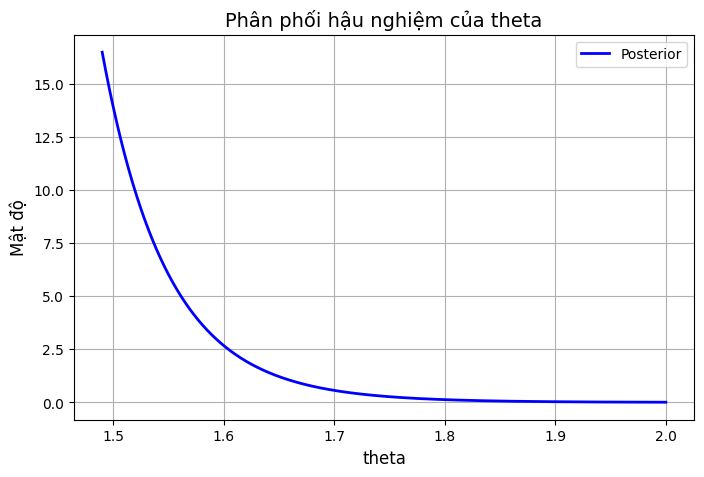

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(theta_grid, posterior, color='blue', lw=2, label="Posterior")
plt.xlabel('theta', fontsize=12)
plt.ylabel("Mật độ", fontsize=12)
plt.title("Phân phối hậu nghiệm của theta", fontsize=14)
plt.legend()
plt.grid(True)
plt.show()

**Nhận xét:** So với sai số các ước trên, thì ước lượng Bayes cố sai số nhỏ nhất, ổn định nhất với thông tin bổ sung $\theta = 1 + e, e \sim Exponential(1)$ và $\theta \le 2$

### **PHẦN II.**

#### $\quad$ **d. Tính hệ số tương quan mẫu giữa $X$ và $Y$.**

Hệ số tương quan mẫu (correlation coefficient) giữa $X$ và $Y$ được tính theo công thức:

$$
r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2}}
$$


In [12]:
def correlation(x, y):
    mean_X = np.mean(x)
    mean_Y = np.mean(y)
    
    sub_x = [i - mean_X for i in x]
    sub_y = [i - mean_Y for i in y]

    numerator = sum([sub_x[i] * sub_y[i] for i in range(len(sub_x))])
    
    std_deviation_x = sum([sub_x[i]**2.0 for i in range(len(sub_x))])
    std_deviation_y = sum([sub_y[i]**2.0 for i in range(len(sub_y))])
    
    denominator = np.sqrt(std_deviation_x * std_deviation_y)

    cor = numerator / denominator
    
    return cor

In [13]:
r = correlation(X, Y)

print(f"Hệ số tương quan mẫu giữa X và Y = {r}")

Hệ số tương quan mẫu giữa X và Y = 0.9260498304309545


#### $\quad$ **e. Kiểm định giả thuyết "$X$ và $Y$ có tương quan" bằng kiểm định hệ số tương quan trong `scipy`**

In [14]:
r, p_value = stats.pearsonr(X, Y)

print("Hệ số tương quan Pearson, r =", r)
print("Giá trị p-value =", p_value)

Hệ số tương quan Pearson, r = 0.9260498304309547
Giá trị p-value = 8.828256624221757e-11


#### $\quad$ **f. Dùng kĩ thuật lấy mẫu lại hoán vị, kiểm định giả thuyết "$X$ và $Y$ có tương quan" và so sánh kết quả với Câu (e)**

In [15]:
n_simulations = 10000
r_perms = np.zeros(n_simulations)

for i in range(n_simulations):
    Y_perm = np.random.permutation(Y)
    r_perms[i] = correlation(X, Y_perm)

p_val_perm = (np.sum(np.abs(r_perms) >= np.abs(r)) + 1) / (n_simulations + 1)
print("p-value theo hoán vị =", p_val_perm)

p-value theo hoán vị = 9.999000099990002e-05


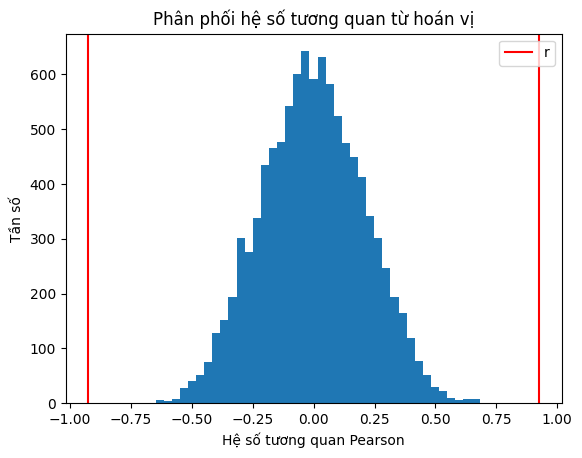

In [16]:
plt.hist(r_perms, bins=40)

plt.axvline(x=r, color='red',label="r")
plt.axvline(x=-r, color='red')

plt.xlabel("Hệ số tương quan Pearson")
plt.ylabel("Tần số")
plt.title("Phân phối hệ số tương quan từ hoán vị")

plt.legend()
plt.show()

### **PHẦN III.**

Xét mô hình hồi qui tuyến tính
$$
Y = a + bX + cX^2  + \epsilon
$$
với $a, b, c$ là các hệ số và $\epsilon$ là lỗi

#### $\quad$ **g. Ước lượng các hệ số hồi qui $a, b, c$**

In [17]:
# Giả sử hệ số lỗi bằng 0
c, b, a = np.polyfit(X, Y, deg=2)

print("Ước lượng các hệ số hồi qui:")
print(f"a = {a}")
print(f"b = {b}")
print(f"c = {c}")

Ước lượng các hệ số hồi qui:
a = 1.0276873197238021
b = -1.0018047731332762
c = 2.0008220230440497


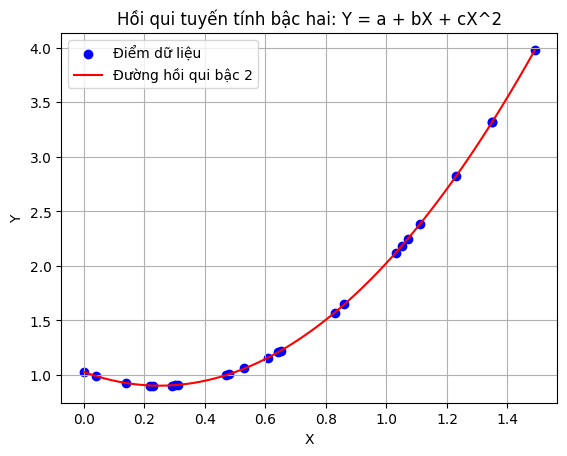

In [18]:
X_grid = np.linspace(min(X), max(X), 1000)
Y_pred = a + b * X_grid + c * (X_grid**2)

plt.scatter(X, Y, color='blue', label="Điểm dữ liệu")
plt.plot(X_grid, Y_pred, color='red', label="Đường hồi qui bậc 2")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Hồi qui tuyến tính bậc hai: Y = a + bX + cX^2")
plt.legend()
plt.grid(True)
plt.show()

#### $\quad$ **h. Dùng kĩ thuật bootstrapping, xây dựng khoảng tin cậy $95\%$ cho $a, b, c$**

In [19]:
B = 10000

a_bootstrap = np.zeros(B)
b_bootstrap = np.zeros(B)
c_bootstrap = np.zeros(B)

for i in range(B):
    indices = np.random.choice(n, n, replace=True)

    X_bt = X[indices]
    Y_bt = Y[indices]

    c_bootstrap[i], b_bootstrap[i], a_bootstrap[i] = np.polyfit(X_bt, Y_bt, deg=2)

a_ci = np.percentile(a_bootstrap, [2.5, 97.5])
b_ci = np.percentile(b_bootstrap, [2.5, 97.5])
c_ci = np.percentile(c_bootstrap, [2.5, 97.5])

In [20]:
print(f"Khoảng tin cậy 95% cho hệ số a: [{a_ci[0]}, {a_ci[1]}]")
print(f"Khoảng tin cậy 95% cho hệ số b: [{b_ci[0]}, {b_ci[1]}]")
print(f"Khoảng tin cậy 95% cho hệ số c: [{c_ci[0]}, {c_ci[1]}]")

Khoảng tin cậy 95% cho hệ số a: [1.0231566260537692, 1.0303657928243404]
Khoảng tin cậy 95% cho hệ số b: [-1.0105270130654298, -0.9875185242813009]
Khoảng tin cậy 95% cho hệ số c: [1.9916355149079787, 2.0063528551029908]


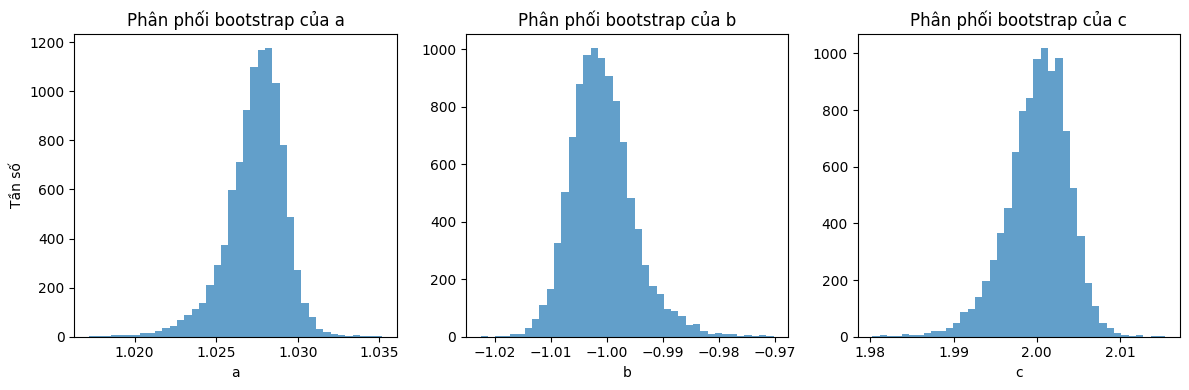

In [21]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.hist(a_bootstrap, bins=40, alpha=0.7)
plt.title("Phân phối bootstrap của a")
plt.xlabel("a")
plt.ylabel("Tần số")

plt.subplot(1,3,2)
plt.hist(b_bootstrap, bins=40, alpha=0.7)
plt.title("Phân phối bootstrap của b")
plt.xlabel("b")

plt.subplot(1,3,3)
plt.hist(c_bootstrap, bins=40, alpha=0.7)
plt.title("Phân phối bootstrap của c")
plt.xlabel("c")

plt.tight_layout()
plt.show()

#### $\quad$ **i. Giả sử ta dùng mô hình hồi qui trên để dự đoán giá trị cho $Y$ là $y_0$ tại $x_0 = 0.5$. Dùng kĩ thuật bootstrapping, ước lượng sai số dự đoán và xây dựng khoảng tin cậy $95\%$ cho $y_0$**

In [22]:
B = 10000

x0 = 0.5
y0_bootstrap = np.zeros(B)

for i in range(B):
    indices = np.random.choice(n, n, replace=True)

    X_bt = X[indices]
    Y_bt = Y[indices]

    c_bt, b_bt, a_bt = np.polyfit(X_bt, Y_bt, deg=2)

    y0_bootstrap[i] = a_bt + b_bt * x0 + c_bt * (x0**2)

se_y0 = np.std(y0_bootstrap, ddof=1)
y0_ci = np.percentile(y0_bootstrap, [2.5, 97.5])

In [23]:
print(f"Giá trị dự đoán bootstrap trung bình = {np.mean(y0_bootstrap)}")
print(f"Ước lượng sai số dự đoán cho y0: {se_y0}")
print(f"Khoảng tin cậy 95% cho y0: [{y0_ci[0], y0_ci[1]}]")

Giá trị dự đoán bootstrap trung bình = 1.0270430933903025
Ước lượng sai số dự đoán cho y0: 0.0008381862562137866
Khoảng tin cậy 95% cho y0: [(1.0253094167845593, 1.028624440227323)]


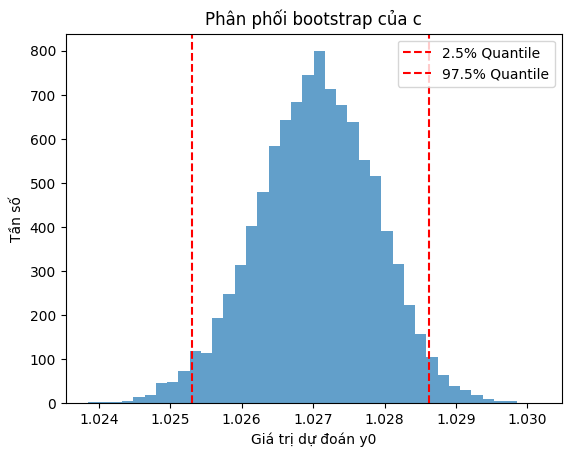

In [24]:
plt.hist(y0_bootstrap, bins=40, alpha=0.7)
plt.title("Phân phối bootstrap của c")
plt.xlabel("Giá trị dự đoán y0")
plt.ylabel("Tần số")

plt.axvline(y0_ci[0], color='red', linestyle='dashed', label="2.5% Quantile")
plt.axvline(y0_ci[1], color='red', linestyle='dashed', label="97.5% Quantile")
plt.legend()
plt.show()

---

## **CÂU 2.**

Tìm  hiểu  bộ  dữ  liệu  Seoul  Bike  Sharing  Demand  tại: 
https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand. Download tập tin dữ liệu 
tại: https://archive.ics.uci.edu/static/public/560/seoul+bike+sharing+demand.zip, lấy ra tập tin 
SeoulBikeData.csv, nạp dữ liệu và bỏ biến (cột) Date. Với bộ dữ liệu này, ta cần phân tích dự 
đoán số lượng xe được thuê (Rented Bike Count). 

$\quad$ a. Nếu chỉ dùng 2 biến khác để dự đoán số lượng xe được thuê thì nên chọn 2 biến nào? 

$\quad$ b. Thực hiện kỹ thuật hồi qui để dự đoán số lượng xe được thuê từ 2 biến đã chọn ở Câu (a) dùng 3 mô hình hồi qui khác nhau từ thư viện scikit-learn. 

$\quad$ c.  Tương tự Câu (b) nhưng dùng kĩ thuật phân tích Bayes với mô hình phù hợp. So sánh kết quả với các mô hình truyền thống ở Câu (b). 

In [25]:
seoul_df = pd.read_csv('SeoulBikeData.csv', encoding = "ISO-8859-1")

seoul_df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [26]:
seoul_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   object 
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(°C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   object 
 12  Holiday                    8760 non-null   object 
 13  Functioning Day            8760 non-null   objec

- Bỏ cột `Date`

In [27]:
seoul_df = seoul_df.drop('Date', axis=1)

seoul_df.head()

,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


#### $\quad$ **a. Nếu chỉ dùng 2 biến khác để dự đoán số lượng xe được thuê thì nên chọn 2 biến nào?** 

Để chọn ra 2 biến khác nhau để dự đoán số lượng xe, ta sẽ xem xét mối tương quan của các biến khác đối với biến `Rented Bike Count`

In [28]:
seoul_df_encoded = pd.get_dummies(seoul_df, drop_first=True)

corr_matrix = seoul_df_encoded.corr()

print(corr_matrix["Rented Bike Count"].sort_values(ascending=False))

Rented Bike Count            1.000000
Temperature(°C)              0.538558
Hour                         0.410257
Dew point temperature(°C)    0.379788
Seasons_Summer               0.296549
Solar Radiation (MJ/m2)      0.261837
Functioning Day_Yes          0.203943
Visibility (10m)             0.199280
Wind speed (m/s)             0.121108
Holiday_No Holiday           0.072338
Seasons_Spring               0.022888
Rainfall(mm)                -0.123074
Snowfall (cm)               -0.141804
Humidity(%)                 -0.199780
Seasons_Winter              -0.424925
Name: Rented Bike Count, dtype: float64


$\to$ Ta chọn 2 biến `Temperature(°C)` và `Hour` để dự đoán số lượng xe được thuê vì đây là 2 biến có mối tương quan mạnh nhất đối với biến `Rented Bike Count`

#### $\quad$ **b. Thực hiện kỹ thuật hồi qui để dự đoán số lượng xe được thuê từ 2 biến đã chọn ở Câu (a) dùng 3 mô hình hồi qui khác nhau từ thư viện scikit-learn**

In [29]:
X = seoul_df[['Temperature(°C)', 'Hour']]
Y = seoul_df['Rented Bike Count']

Chia tập dữ liệu thành tập train và tập test

In [30]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((7008, 2), (1752, 2), (7008,), (1752,))

Xây dựng và huấn luyện mô hình

- Linear Regression

In [31]:
linear_regression = LinearRegression()

linear_regression.fit(X_train, Y_train)
Y_predicted_lr = linear_regression.predict(X_test)

mse_lr = mean_squared_error(Y_test, Y_predicted_lr)
r2_lr = r2_score(Y_test, Y_predicted_lr)

In [32]:
print("Linear Regression:")
print(f"- MSE = {mse_lr}")
print(f"- R2 = {r2_lr}")

Linear Regression:
- MSE = 252429.81884713323
- R2 = 0.39413872969187946


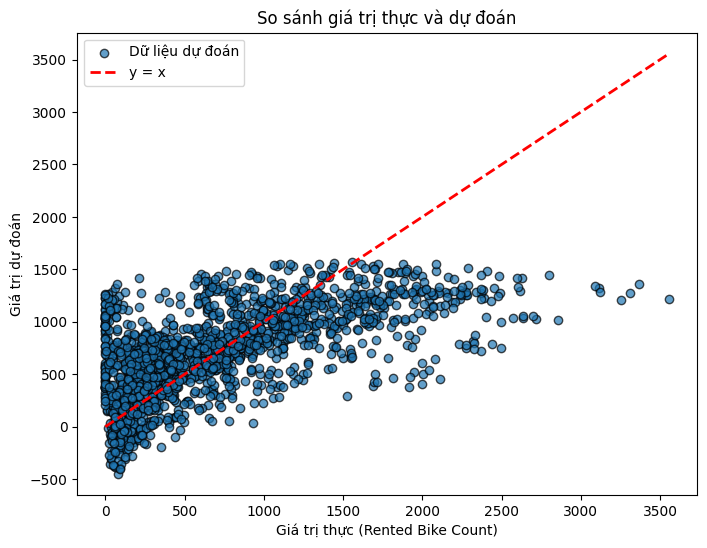

In [33]:
plt.figure(figsize=(8, 6))

plt.scatter(Y_test, Y_predicted_lr, alpha=0.7, edgecolor='k', label='Dữ liệu dự đoán')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], '--r', lw=2, label='y = x')
plt.xlabel("Giá trị thực (Rented Bike Count)")
plt.ylabel("Giá trị dự đoán")
plt.title("So sánh giá trị thực và dự đoán")

plt.legend()
plt.show()

- Decision Tree Regression

In [34]:
decision_tree = DecisionTreeRegressor(random_state=42)

decision_tree.fit(X_train, Y_train)
Y_predicted_dt = decision_tree.predict(X_test)

mse_dt = mean_squared_error(Y_test, Y_predicted_dt)
r2_dt = r2_score(Y_test, Y_predicted_dt)

In [35]:
print("Decision Tree Regression:")
print(f"- MSE = {mse_dt}")
print(f"- R2 = {r2_dt}")

Decision Tree Regression:
- MSE = 327146.61624746316
- R2 = 0.2148096235147211


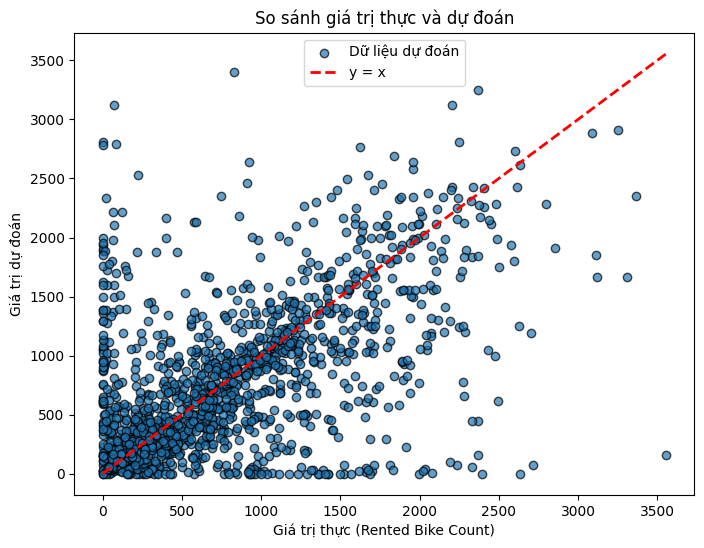

In [36]:
plt.figure(figsize=(8, 6))

plt.scatter(Y_test, Y_predicted_dt, alpha=0.7, edgecolor='k', label='Dữ liệu dự đoán')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], '--r', lw=2, label='y = x')
plt.xlabel("Giá trị thực (Rented Bike Count)")
plt.ylabel("Giá trị dự đoán")
plt.title("So sánh giá trị thực và dự đoán")

plt.legend()
plt.show()

- Random Forest Regression

In [37]:
random_forest = RandomForestRegressor(n_estimators=100, random_state=42)

random_forest.fit(X_train, Y_train)
Y_predicted_rf = random_forest.predict(X_test)

mse_rf =  mean_squared_error(Y_test, Y_predicted_rf)
r2_rf = r2_score(Y_test, Y_predicted_rf)

In [38]:
print("Random Forest Regression:")
print(f"- MSE = {mse_rf}")
print(f"- R2 = {r2_rf}")

Random Forest Regression:
- MSE = 235301.86570491447
- R2 = 0.43524783279196455


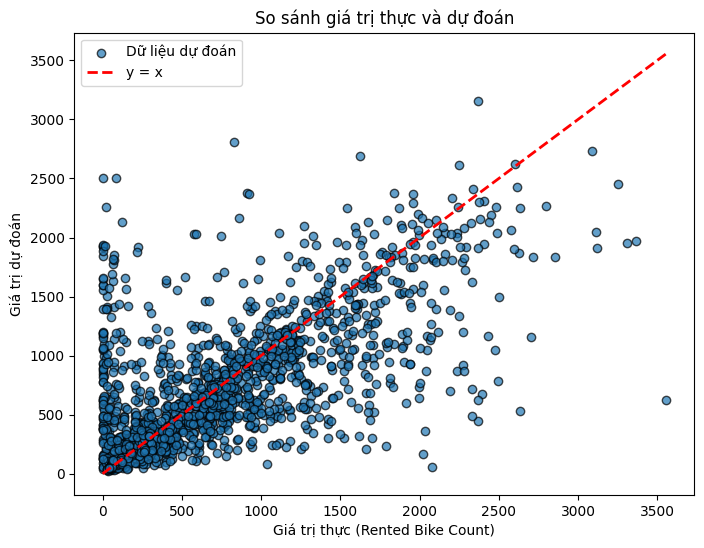

In [39]:
plt.figure(figsize=(8, 6))

plt.scatter(Y_test, Y_predicted_rf, alpha=0.7, edgecolor='k', label='Dữ liệu dự đoán')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], '--r', lw=2, label='y = x')
plt.xlabel("Giá trị thực (Rented Bike Count)")
plt.ylabel("Giá trị dự đoán")
plt.title("So sánh giá trị thực và dự đoán")

plt.legend()
plt.show()

$\Rightarrow$ Kết luận chung:
- Decision Tree Regression là mô hình có hiệu quả kém nhất.
- Random Forest Regression là mô hình có hiệu tốt nhất trong 3 mô hình.

#### $\quad$ **c.  Tương tự Câu (b) nhưng dùng kĩ thuật phân tích Bayes với mô hình phù hợp. So sánh kết quả với các mô hình truyền thống ở Câu (b).**

In [40]:
bayesian_regression = BayesianRidge()

bayesian_regression.fit(X_train, Y_train)
Y_predicted_bayesian = bayesian_regression.predict(X_test)

mse_bayesian = mean_squared_error(Y_test, Y_predicted_bayesian)
r2_bayesian = r2_score(Y_test, Y_predicted_bayesian)


In [41]:
print("Bayesian Regression:")   
print(f"- MSE = {mse_bayesian}")
print(f"- R2 = {r2_bayesian}")

Bayesian Regression:
- MSE = 252419.89270893284
- R2 = 0.3941625535916342


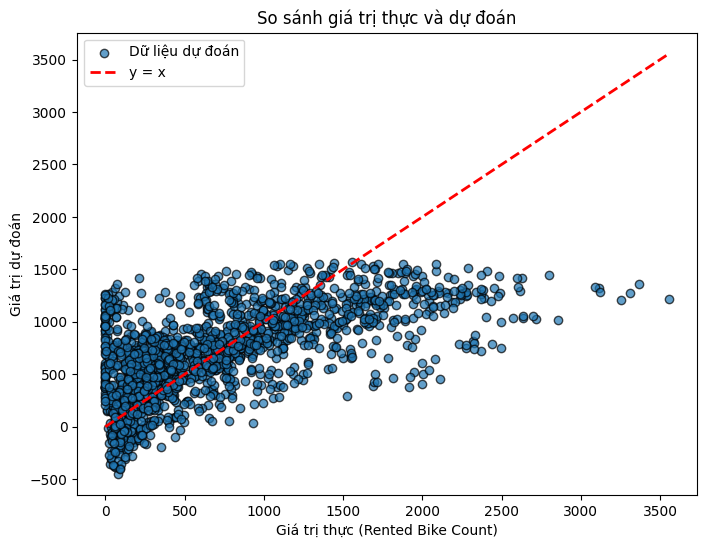

In [42]:
plt.figure(figsize=(8, 6))

plt.scatter(Y_test, Y_predicted_bayesian, alpha=0.7, edgecolor='k', label='Dữ liệu dự đoán')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], '--r', lw=2, label='y = x')
plt.xlabel("Giá trị thực (Rented Bike Count)")
plt.ylabel("Giá trị dự đoán")
plt.title("So sánh giá trị thực và dự đoán")

plt.legend()
plt.show()

In [43]:
model_results = {
    "Model": ["Linear Regression", "Decision Tree Regression", "Random Forest Regression", "Bayesian Regression"],
    "MSE": [mse_lr, mse_dt, mse_rf, mse_bayesian],
    "R²": [r2_lr, r2_dt, r2_rf, r2_bayesian]
}

regr_results_df = pd.DataFrame(model_results)

regr_results_df

,Model,MSE,R²
0,Linear Regression,252429.818847,0.394139
1,Decision Tree Regression,327146.616247,0.214810
2,Random Forest Regression,235301.865705,0.435248
3,Bayesian Regression,252419.892709,0.394163


$\Rightarrow$ Nhận xét chung:
- Các giá trị MSE và R2 của mô hình Bayesian Regression đều gần với các giá trị của mô hình Random Forest Regression. Tuy nhiên, mô hình Random Forest Regression vẫn tốt hơn.
- Và mô hình Bayesian Regression lại tốt hơn các mô hình còn lại.

---

## **CÂU 3.**

Tìm  hiểu  bộ  dữ  liệu  Breast  Cancer  Wisconsin  (Original)  tại: https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original. Download tập tin dữ  liệu tại: https://archive.ics.uci.edu/static/public/15/breast+cancer+wisconsin+original.zip, lấy ra tập tin breast-cancer-wisconsin.data, nạp dữ liệu và bỏ biến Sample code number. Trong  bộ dữ liệu này, ta cần phân tích dự đoán ung thư (class) theo các biến khác. 

$\quad$ a. Thực hiện việc phân lớp dùng 3 mô hình phân lớp khác nhau từ thư viện scikit-learn. 

$\quad$ b. Tương tự Câu (a) nhưng dùng kĩ thuật phân tích Bayes với mô hình phù hợp. So sánh kết quả với các mô hình truyền thống ở Câu (a). 

$\quad$ c.  Dùng kĩ thuật kiểm tra chéo, chọn ra mô hình “tốt nhất” giải thích ung thư (class) theo các đặc trưng (các biến còn lại). 

$\quad$ d. Ta thấy rằng tỉ lệ mẫu ung thư (class là 4 - malignant) thấp hơn đáng kể so với mẫu lành tính (2 - benign), vấn đề này được gọi là mất cân bằng lớp (class imbalance). Tìm hiểu vấn đề mất cân bằng lớp và thư viện imbalanced-learn (https://imbalanced-learn.org/stable/index.html) là thư viện hỗ trợ các kĩ thuật giải quyết vấn đề mất cân bằng lớp. Chọn 1 thuật toán tăng mẫu (over-sampling) và 1 thuật toán giảm mẫu (under-sampling) từ thư viện imbalanced-learn để thực hiện lại Câu (a) và so sánh các kết quả. 

---

- Đọc và tiền xử lý dữ liệu

In [44]:
column_names = ['Sample code number', 'Clump Thickness', 'Uniformity of Cell Size', 'Uniformity of Cell Shape', 'Marginal Adhesion', 
                'Single Epithelial Cell Size', 'Bare Nuclei', 'Bland Chromatin', 'Normal Nucleoli', 'Mitoses', 'Class']

In [45]:
cancer_df = pd.read_csv('breast-cancer-wisconsin.data', header=None, names=column_names)

cancer_df.head()

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [46]:
cancer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Sample code number           699 non-null    int64 
 1   Clump Thickness              699 non-null    int64 
 2   Uniformity of Cell Size      699 non-null    int64 
 3   Uniformity of Cell Shape     699 non-null    int64 
 4   Marginal Adhesion            699 non-null    int64 
 5   Single Epithelial Cell Size  699 non-null    int64 
 6   Bare Nuclei                  699 non-null    object
 7   Bland Chromatin              699 non-null    int64 
 8   Normal Nucleoli              699 non-null    int64 
 9   Mitoses                      699 non-null    int64 
 10  Class                        699 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.2+ KB


In [47]:
cancer_df.drop(columns=['Sample code number'], inplace=True)

cancer_df.head()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2


In [48]:
print(f"- Giá trị unique trong cột 'Bare Nuclei': \n {cancer_df['Bare Nuclei'].unique()}")

- Giá trị unique trong cột 'Bare Nuclei': 
 ['1' '10' '2' '4' '3' '9' '7' '?' '5' '8' '6']


In [49]:
cancer_df = cancer_df.replace('?', pd.NA)

In [50]:
cancer_df['Bare Nuclei'] = pd.to_numeric(cancer_df['Bare Nuclei'], errors='coerce')

cancer_df = cancer_df.dropna().reset_index(drop=True)

cancer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 683 entries, 0 to 682
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Clump Thickness              683 non-null    int64  
 1   Uniformity of Cell Size      683 non-null    int64  
 2   Uniformity of Cell Shape     683 non-null    int64  
 3   Marginal Adhesion            683 non-null    int64  
 4   Single Epithelial Cell Size  683 non-null    int64  
 5   Bare Nuclei                  683 non-null    float64
 6   Bland Chromatin              683 non-null    int64  
 7   Normal Nucleoli              683 non-null    int64  
 8   Mitoses                      683 non-null    int64  
 9   Class                        683 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 53.5 KB


### $\quad$ **a. Thực hiện việc phân lớp dùng 3 mô hình phân lớp khác nhau từ thư viện scikit-learn.**

In [51]:
X = cancer_df.drop(columns=['Class'])
Y = cancer_df['Class']

Chia tập dữ liệu thành tập train và tập test

In [52]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((546, 9), (137, 9), (546,), (137,))

Xây dựng và huấn luyện mô hình

- Logistic Regression:

In [53]:
logistic_regression = LogisticRegression(max_iter=1000, random_state=42)

logistic_regression.fit(X_train, Y_train)
Y_predicted_logistic = logistic_regression.predict(X_test)

accuracy_logistic = accuracy_score(Y_test, Y_predicted_logistic)
report_logistic = classification_report(Y_test, Y_predicted_logistic, target_names=['Benign', 'Malignant'])
conf_matrix_logistic = confusion_matrix(Y_test, Y_predicted_logistic)


In [54]:
conf_matrix_dt_df = pd.DataFrame(conf_matrix_logistic, 
                              index=['Benign (Actual)', 'Malignant (Actual)'], 
                              columns=['Benign (Predicted)', 'Malignant (Predicted)'])

In [55]:
print("Logistic Regression:")
print(f"- Accuracy = {accuracy_logistic}\n")
print(f"- Confusion Matrix:\n {conf_matrix_dt_df}\n")
print(f"- Classification Report:\n {report_logistic}")

Logistic Regression:
- Accuracy = 0.9562043795620438

- Confusion Matrix:
                     Benign (Predicted)  Malignant (Predicted)
Benign (Actual)                     78                      1
Malignant (Actual)                   5                     53

- Classification Report:
               precision    recall  f1-score   support

      Benign       0.94      0.99      0.96        79
   Malignant       0.98      0.91      0.95        58

    accuracy                           0.96       137
   macro avg       0.96      0.95      0.95       137
weighted avg       0.96      0.96      0.96       137



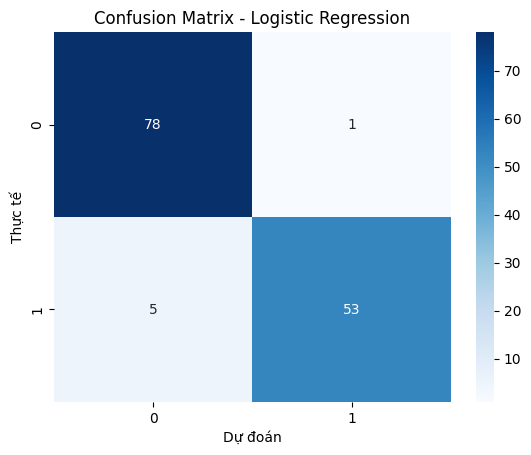

In [56]:
sns.heatmap(conf_matrix_logistic, annot=True, cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")

plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')

plt.show()

- Decision Tree Classifier

In [57]:
decision_tree_classifier = DecisionTreeClassifier(random_state=42)

decision_tree_classifier.fit(X_train, Y_train)
Y_predicted_dt_classifier = decision_tree_classifier.predict(X_test)

accuracy_dt_classifier = accuracy_score(Y_test, Y_predicted_dt_classifier)
report_dt_classifier = classification_report(Y_test, Y_predicted_dt_classifier, target_names=['Benign', 'Malignant'])
conf_matrix_dt_classifier = confusion_matrix(Y_test, Y_predicted_dt_classifier)

In [58]:
conf_matrix_dt_classifier_df = pd.DataFrame(conf_matrix_dt_classifier,
                              index=['Benign (Actual)', 'Malignant (Actual)'], 
                              columns=['Benign (Predicted)', 'Malignant (Predicted)'])

In [59]:
print("Decision Tree Classifier:")
print(f"- Accuracy = {accuracy_dt_classifier}\n")
print(f"- Confusion Matrix:\n {conf_matrix_dt_classifier_df}\n")
print(f"- Classification Report:\n {report_dt_classifier}")

Decision Tree Classifier:
- Accuracy = 0.9343065693430657

- Confusion Matrix:
                     Benign (Predicted)  Malignant (Predicted)
Benign (Actual)                     77                      2
Malignant (Actual)                   7                     51

- Classification Report:
               precision    recall  f1-score   support

      Benign       0.92      0.97      0.94        79
   Malignant       0.96      0.88      0.92        58

    accuracy                           0.93       137
   macro avg       0.94      0.93      0.93       137
weighted avg       0.94      0.93      0.93       137



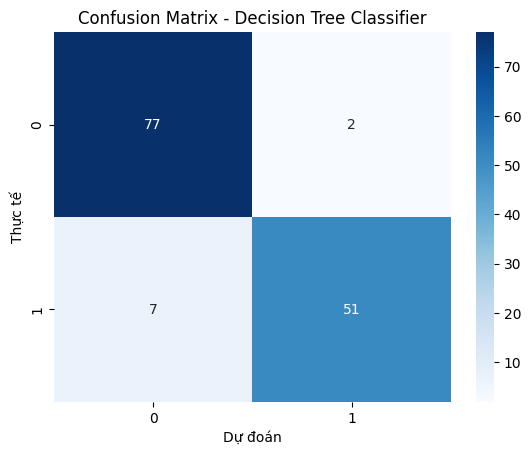

In [60]:
sns.heatmap(conf_matrix_dt_classifier, annot=True, cmap='Blues')

plt.title("Confusion Matrix - Decision Tree Classifier")

plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')

plt.show()

- Random Forest Classifier

In [61]:
random_forest_classifier = RandomForestClassifier(n_estimators=1000, random_state=42)

random_forest_classifier.fit(X_train, Y_train)
Y_predicted_rf_classifier = random_forest_classifier.predict(X_test)

accuracy_rf_classifier = accuracy_score(Y_test, Y_predicted_rf_classifier)
report_rf_classifier = classification_report(Y_test, Y_predicted_rf_classifier, target_names=['Benign', 'Malignant'])
conf_matrix_rf_classifier = confusion_matrix(Y_test, Y_predicted_rf_classifier)

In [62]:
conf_matrix_rf_classifier_df = pd.DataFrame(conf_matrix_rf_classifier, 
                              index=['Benign (Actual)', 'Malignant (Actual)'], 
                              columns=['Benign (Predicted)', 'Malignant (Predicted)'])

In [63]:
print("Random Forest Classifier:")
print(f"- Accuracy = {accuracy_rf_classifier}\n")       
print(f"- Confusion Matrix:\n {conf_matrix_rf_classifier_df}\n")
print(f"- Classification Report:\n {report_rf_classifier}")

Random Forest Classifier:
- Accuracy = 0.948905109489051

- Confusion Matrix:
                     Benign (Predicted)  Malignant (Predicted)
Benign (Actual)                     78                      1
Malignant (Actual)                   6                     52

- Classification Report:
               precision    recall  f1-score   support

      Benign       0.93      0.99      0.96        79
   Malignant       0.98      0.90      0.94        58

    accuracy                           0.95       137
   macro avg       0.95      0.94      0.95       137
weighted avg       0.95      0.95      0.95       137



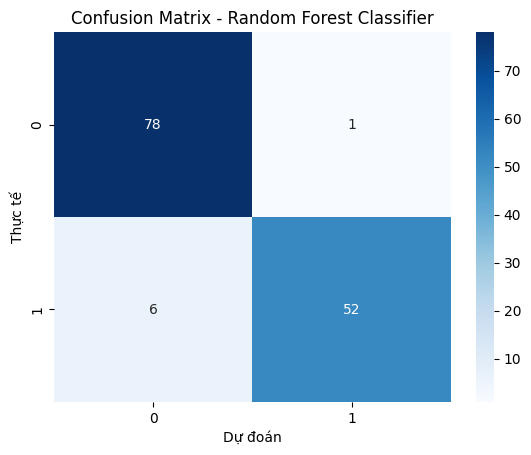

In [64]:
sns.heatmap(conf_matrix_rf_classifier, annot=True, cmap='Blues')

plt.title("Confusion Matrix - Random Forest Classifier")

plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')

plt.show()

$\Rightarrow$ Nhận xét chung:
- Mô hình Logistic Regression là tốt nhất với độ dự đoán chính xác đạt khoảng 96%, sau đó, lần lượt tới mô hình Random Forest Classifier và Decision Tree Classifier.
- Kết quả Recall cho từng kết quả ung thư đều khá cao.
- Ma trận nhầm lẫn:
    - Decision Tree Classifier có nhiều FN nhất nên có nguy cơ bỏ sót ca ác tính cao hơn.
    - Logistic và Random Forest đều chỉ bỏ sót 5–6 ca.

### $\quad$ **b. Tương tự Câu (a) nhưng dùng kĩ thuật phân tích Bayes với mô hình phù hợp. So sánh kết quả với các mô hình truyền thống ở Câu (a).**

In [65]:
navie_bayes = GaussianNB()

navie_bayes.fit(X_train, Y_train)
Y_predicted_navie_bayes =  navie_bayes.predict(X_test)

accuracy_nb = accuracy_score(Y_test, Y_predicted_navie_bayes)
report_nb = classification_report(Y_test, Y_predicted_navie_bayes, target_names=['Benign', 'Malignant'])
conf_matrix_nb = confusion_matrix(Y_test, Y_predicted_navie_bayes)

In [66]:
conf_matrix_nb_df = pd.DataFrame(conf_matrix_nb,
                                 index=['Benign (Actual)', 'Malignant (Actual)'],
                                 columns=['Benign (Predicted)', 'Malignant (Predicted)'])

In [67]:
print("Gaussian Naive Bayes:")
print(f"- Accuracy: {accuracy_nb}\n")
print(f"- Confusion Matrix: \n {conf_matrix_nb_df}\n")
print(f"- Classification Report:\n {report_nb}")

Gaussian Naive Bayes:
- Accuracy: 0.9562043795620438

- Confusion Matrix: 
                     Benign (Predicted)  Malignant (Predicted)
Benign (Actual)                     76                      3
Malignant (Actual)                   3                     55

- Classification Report:
               precision    recall  f1-score   support

      Benign       0.96      0.96      0.96        79
   Malignant       0.95      0.95      0.95        58

    accuracy                           0.96       137
   macro avg       0.96      0.96      0.96       137
weighted avg       0.96      0.96      0.96       137



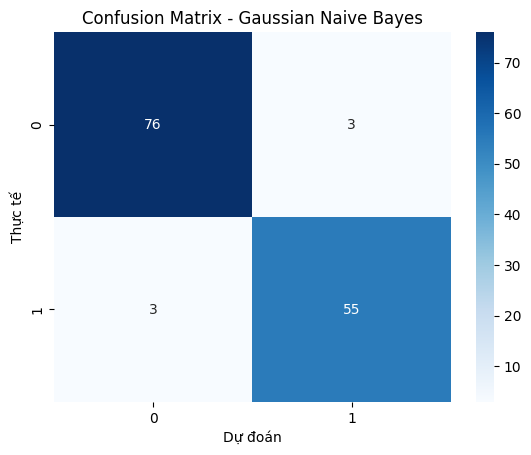

In [68]:
sns.heatmap(conf_matrix_nb, annot=True, cmap='Blues')

plt.title("Confusion Matrix - Gaussian Naive Bayes")

plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")

plt.show()

In [69]:
report_logistic_dict = classification_report(Y_test, Y_predicted_logistic, target_names=['Benign', 'Malignant'], output_dict=True)
report_dt_dict = classification_report(Y_test, Y_predicted_dt_classifier, target_names=['Benign', 'Malignant'], output_dict=True)
report_rf_dict = classification_report(Y_test, Y_predicted_rf_classifier, target_names=['Benign', 'Malignant'], output_dict=True)
report_nb_dict = classification_report(Y_test, Y_predicted_navie_bayes, target_names=['Benign', 'Malignant'], output_dict=True)

In [70]:
reports = [report_logistic_dict, report_dt_dict, report_rf_dict, report_nb_dict]

classification_results = {
    "Classification Model": ["Logistic Regression", "Decision Tree", "Random Forest", "Gaussian Naive Bayes"],
    "Accuracy": [accuracy_logistic, accuracy_dt_classifier, accuracy_rf_classifier, accuracy_nb],
    "Precision (Mal.)": [report['Malignant']['precision'] for report in reports],
    "Recall (Mal.)": [report['Malignant']['recall'] for report in reports],
    "F1 score (Mal.)": [report['Malignant']['f1-score'] for report in reports],
    "Support (Mal.)": [report['Malignant']['support'] for report in reports]
}

classification_results_df = pd.DataFrame(classification_results)

classification_results_df

,Classification Model,Accuracy,Precision (Mal.),Recall (Mal.),F1 score (Mal.),Support (Mal.)
0,Logistic Regression,0.956204,0.981481,0.913793,0.946429,58.0
1,Decision Tree,0.934307,0.962264,0.879310,0.918919,58.0
2,Random Forest,0.948905,0.981132,0.896552,0.936937,58.0
3,Gaussian Naive Bayes,0.956204,0.948276,0.948276,0.948276,58.0


$\Rightarrow$ Nhận xét chung:
- Accuracy - Tỉ lệ $\%$ tổng thể các dự đoán đúng:
    - Logistic Regression và Naive Bayes là 2 mô hình có tỉ lệ dự đoán đúng cao nhất, đạt khoảng $95.62\%$
    - Lần lượt theo sau đó là mô hình phân lớp Random Forest và Decision Tree, với tỉ lệ dự đoán đạt $94.89\%$ và $93.43\%$

- Precision (Mal.) - Tỉ lệ $\%$ thật sự là ác tính (Malignant) trong tổng số dự đoán ác tính:
    - Logistic Regression là mô hình dẫn đầu về giá trị này (xấp xĩ $98.1481\%$). Không kém cạnh đó là mô hình phân lớp Random Forest, với giá trị đạt khoảng $98.1132\%$. Nghĩa là rất ít ca lành tính bị nhầm là ác tính.
    - Naive Bayes lại là mô hình có tỉ lệ precision lại thấp nhất trong tất cả các mô hình.

- Recall (Mal.) - Tỉ lệ $\%$ dự đoán đúng là ác tính trong các mẫu thực tế là ác tính:
    - Naive Bayes có giá trị recall tốt nhất đạt gần $95\%$. Mô hình phân lớp Logistic Regression cũng khá tốt với mức $91.37\%$.
    - 2 mô hình phân lớp còn lại có giá trị đạt dưới mức 90%, trong đó thấp nhất là mô hình Decision Tree (khoảng $87.93\%$), có nguy cơ bỏ lỡ các ca mắc bệnh ung thư ác tính.

- F1 score (Mal.) - Trung bình của precision và recall:
    - Mô hình Navie Bayes lại tiếp tục dẫn đầu về giá trị f1-score - $94.82\%$. Logistic Regression cũng không thua kém có giá trị đạt xấp xĩ $94.64\%$.
    - Mô hình phân lớp Decision Tree có giá trị trung bình của precision và recall là thấp nhất - $91.89\%$.

- Support (Mal.) - Số lượng mẫu thực tế có trong tập test là ác tính

$\to$ Nhìn tổng thể thì mô hình Naive Bayes khá tốt về mọi mặt.

### $\quad$ **c.  Dùng kĩ thuật kiểm tra chéo, chọn ra mô hình “tốt nhất” giải thích ung thư (class) theo các đặc trưng (các biến còn lại).**

In [71]:
classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=1000, random_state=42),
    "Gaussian Naive Bayes": GaussianNB()
}

In [72]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [73]:
cv_results = []

for name, model in classification_models.items():
    score = cross_val_score(model, X, Y, cv=kf, scoring='accuracy')

    cv_results.append({
        "Classification Model": name, 
        "Mean Accuracy": score.mean(),
        "Std Accuracy": score.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values('Mean Accuracy', ascending=False, ignore_index=True)

cv_results_df

,Classification Model,Mean Accuracy,Std Accuracy
0,Random Forest,0.969257,0.005469
1,Logistic Regression,0.964878,0.008472
2,Gaussian Naive Bayes,0.960455,0.017059
3,Decision Tree,0.941445,0.006447


$\to$ Kết luận chung:
- Trong tất cả các mô hình, thì `Random Forest` là mô hình tốt nhất khi vừa có độ chính xác trung bình (Mean Accuracy) cao nhất ($96.93\%$) và sai số chuẩn(Std Accuracy) thấp nhất ($0.0055$).
- Logistic Regression và Gaussuan Naive Bayes có độ chính xác trung bình tương đương nhau ($\approx 96\%$) nhưng Gausian Naive Bayes lại có giá trị sai số chuẩn cao hơn và cao nhất trong tất cả.
- Mô hình phân lớp Decision Tree lại có độ chính xác trung bình thấp nhất ($94.14\%$) với giá trị sai số chuẩn ($0.0065$).

### $\quad$ **d. Ta thấy rằng tỉ lệ mẫu ung thư (class là 4 - malignant) thấp hơn đáng kể so với mẫu lành tính (2 - benign), vấn đề này được gọi là mất cân bằng lớp (class imbalance). Tìm hiểu vấn đề mất cân bằng lớp và thư viện imbalanced-learn (https://imbalanced-learn.org/stable/index.html) là thư viện hỗ trợ các kĩ thuật giải quyết vấn đề mất cân bằng lớp. Chọn 1 thuật toán tăng mẫu (over-sampling) và 1 thuật toán giảm mẫu (under-sampling) từ thư viện imbalanced-learn để thực hiện lại Câu (a) và so sánh các kết quả.**

##### **Over-sampling**

In [74]:
smote = SMOTE(random_state=42)

X_resampled_smote, Y_resampled_smote = smote.fit_resample(X_train, Y_train)

Logistic Regression after over-sampling
- Accuracy = 0.9708029197080292
- Confusion Matrix:
                     Benign (Predicted)  Malignant (Predicted)
Benign (Actual)                     78                      1
Malignant (Actual)                   3                     55

- Classification Report:
               precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        79
   Malignant       0.98      0.95      0.96        58

    accuracy                           0.97       137
   macro avg       0.97      0.97      0.97       137
weighted avg       0.97      0.97      0.97       137




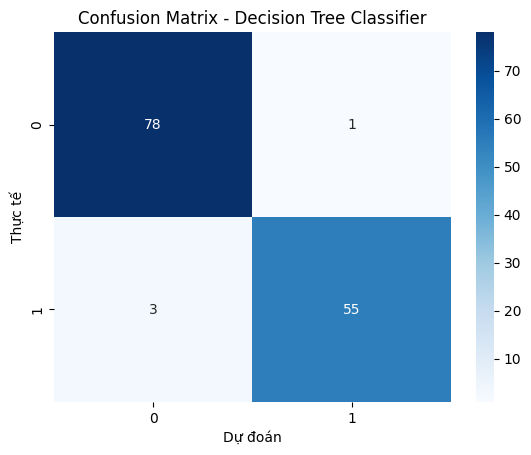

-----------------------------------------------------------------------------

Decision Tree after over-sampling
- Accuracy = 0.9197080291970803
- Confusion Matrix:
                     Benign (Predicted)  Malignant (Predicted)
Benign (Actual)                     75                      4
Malignant (Actual)                   7                     51

- Classification Report:
               precision    recall  f1-score   support

      Benign       0.91      0.95      0.93        79
   Malignant       0.93      0.88      0.90        58

    accuracy                           0.92       137
   macro avg       0.92      0.91      0.92       137
weighted avg       0.92      0.92      0.92       137




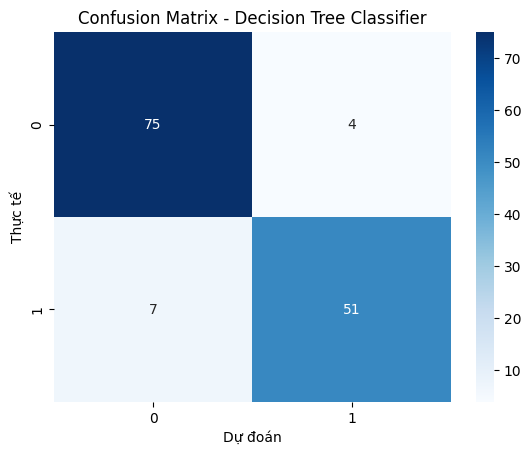

-----------------------------------------------------------------------------

Random Forest after over-sampling
- Accuracy = 0.9708029197080292
- Confusion Matrix:
                     Benign (Predicted)  Malignant (Predicted)
Benign (Actual)                     76                      3
Malignant (Actual)                   1                     57

- Classification Report:
               precision    recall  f1-score   support

      Benign       0.99      0.96      0.97        79
   Malignant       0.95      0.98      0.97        58

    accuracy                           0.97       137
   macro avg       0.97      0.97      0.97       137
weighted avg       0.97      0.97      0.97       137




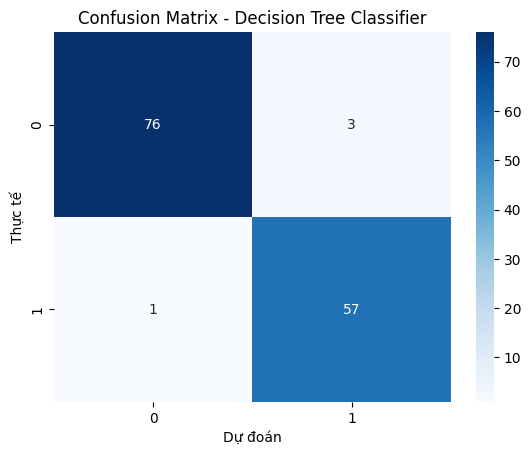

-----------------------------------------------------------------------------

Gaussian Naive Bayes after over-sampling
- Accuracy = 0.9635036496350365
- Confusion Matrix:
                     Benign (Predicted)  Malignant (Predicted)
Benign (Actual)                     76                      3
Malignant (Actual)                   2                     56

- Classification Report:
               precision    recall  f1-score   support

      Benign       0.97      0.96      0.97        79
   Malignant       0.95      0.97      0.96        58

    accuracy                           0.96       137
   macro avg       0.96      0.96      0.96       137
weighted avg       0.96      0.96      0.96       137




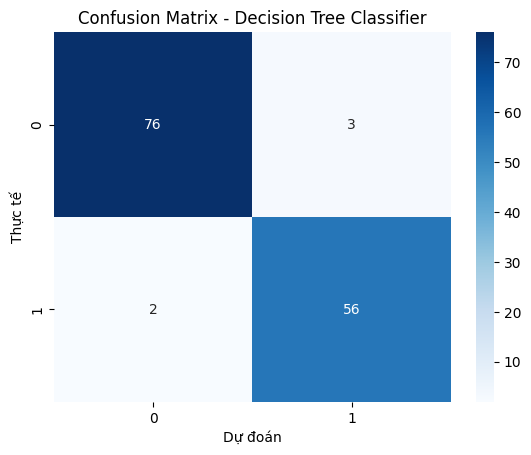

-----------------------------------------------------------------------------



In [75]:
for name, model in classification_models.items():
    model.fit(X_resampled_smote, Y_resampled_smote)
    Y_pred = model.predict(X_test)

    acc = accuracy_score(Y_test, Y_pred)
    report = classification_report(Y_test, Y_pred, target_names=['Benign', 'Malignant'])
    conf_matrix = confusion_matrix(Y_test, Y_pred)
    conf_matrix_df = pd.DataFrame(conf_matrix,
                    index=['Benign (Actual)', 'Malignant (Actual)'], 
                    columns=['Benign (Predicted)', 'Malignant (Predicted)'])

    print(f"{name} after over-sampling")
    print(f"- Accuracy = {acc}")
    print(f"- Confusion Matrix:\n {conf_matrix_df}\n")
    print(f"- Classification Report:\n {report}\n")

    # Trực quan confusion matrix
    sns.heatmap(conf_matrix, annot=True, cmap='Blues')

    plt.title("Confusion Matrix - Decision Tree Classifier")

    plt.xlabel('Dự đoán')
    plt.ylabel('Thực tế')

    plt.show()

    print("-----------------------------------------------------------------------------\n")

**Nhận xét chung:** So với trước khi over-sampling bằng thuật toán SMOTE:
- Logistic Regression:
    - Độ chính xác (accuracy) tăng từ $95.62\%$ lên $97.08\%$.
    - Số ca thực tế là ác tính mà được dự đoán là lành tính (FN) giảm từ 5 ca xuống 3 ca, cải thiện chất lượng.
    - Giá trị precision (Mal.) vẫn giữ nguyên, nhưng giá trị recall tăng lên $0.95$, cho thấy mô hình đã nâng cao chất lượng trong việc phát hiện ca ác tính.
    - f1-score cũng tăng $0.1$, nghĩa là tăng độ cân bằng giữ precision và recall.

- Decision Tree:
    - Độ chính xác đã giảm nhẹ từ $93.43\%$ xuống còn $91.97\%$ do số lượng ở FP tăng (từ 2 lên 4), tức nhiều mẫu lành tính bị nhầm thành ác tính hơn.
    - Ngoài giá trị recall của ác tính giữ nguyên thì các giá trị còn lại (precision, f1-score) đều có phần giảm nhẹ khoarg $0.2-0.3$.

- Random Forest:
    - Độ chính xác được cải thiện, trước khi resample đạt $94.89\%$, sau tăng lên $97.08\%$ vì đã giảm mạnh dự đoán nhầm số ca ác tính (từ 6 ca xuống con 1 ca).
    - Tăng phát hiện ca ác tính, nghĩa là recall Malignant tăng từ $0.90$ lên $0.98$. Và độ điều hòa f1-score cũng tăng lên $0.3$.


##### **Under-sampling**

In [76]:
rus = RandomUnderSampler(random_state=42)

X_resampled_rus, Y_resampled_rus = rus.fit_resample(X_train, Y_train)

Logistic Regression after under-sampling
- Accuracy = 0.9781021897810219
- Confusion Matrix:
                     Benign (Predicted)  Malignant (Predicted)
Benign (Actual)                     78                      1
Malignant (Actual)                   2                     56

- Classification Report:
               precision    recall  f1-score   support

      Benign       0.97      0.99      0.98        79
   Malignant       0.98      0.97      0.97        58

    accuracy                           0.98       137
   macro avg       0.98      0.98      0.98       137
weighted avg       0.98      0.98      0.98       137




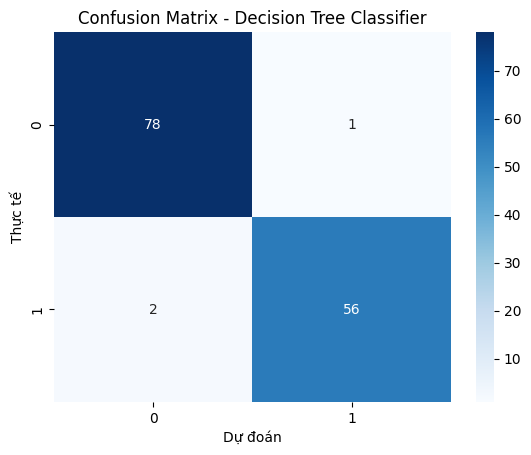

-----------------------------------------------------------------------------

Decision Tree after under-sampling
- Accuracy = 0.9343065693430657
- Confusion Matrix:
                     Benign (Predicted)  Malignant (Predicted)
Benign (Actual)                     75                      4
Malignant (Actual)                   5                     53

- Classification Report:
               precision    recall  f1-score   support

      Benign       0.94      0.95      0.94        79
   Malignant       0.93      0.91      0.92        58

    accuracy                           0.93       137
   macro avg       0.93      0.93      0.93       137
weighted avg       0.93      0.93      0.93       137




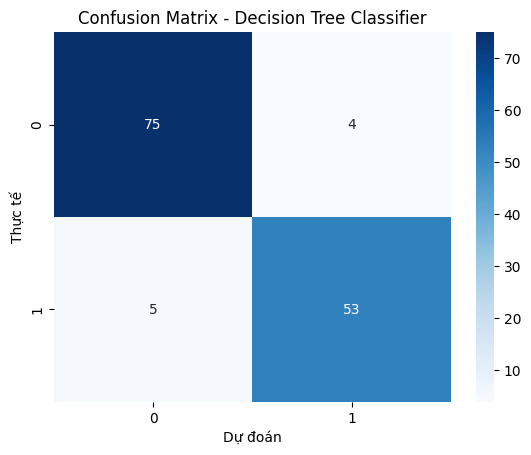

-----------------------------------------------------------------------------

Random Forest after under-sampling
- Accuracy = 0.9635036496350365
- Confusion Matrix:
                     Benign (Predicted)  Malignant (Predicted)
Benign (Actual)                     77                      2
Malignant (Actual)                   3                     55

- Classification Report:
               precision    recall  f1-score   support

      Benign       0.96      0.97      0.97        79
   Malignant       0.96      0.95      0.96        58

    accuracy                           0.96       137
   macro avg       0.96      0.96      0.96       137
weighted avg       0.96      0.96      0.96       137




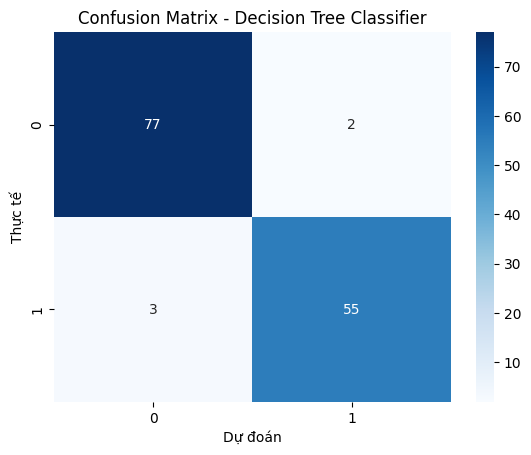

-----------------------------------------------------------------------------

Gaussian Naive Bayes after under-sampling
- Accuracy = 0.9562043795620438
- Confusion Matrix:
                     Benign (Predicted)  Malignant (Predicted)
Benign (Actual)                     76                      3
Malignant (Actual)                   3                     55

- Classification Report:
               precision    recall  f1-score   support

      Benign       0.96      0.96      0.96        79
   Malignant       0.95      0.95      0.95        58

    accuracy                           0.96       137
   macro avg       0.96      0.96      0.96       137
weighted avg       0.96      0.96      0.96       137




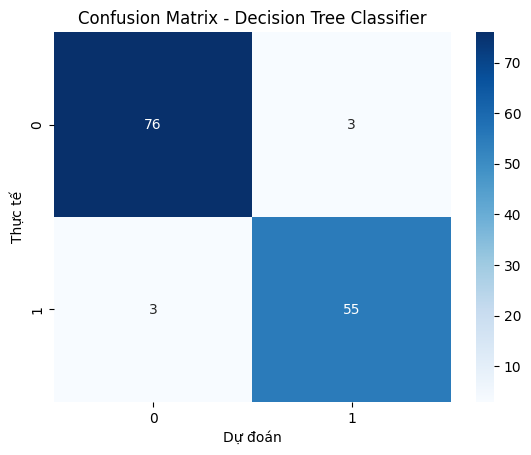

-----------------------------------------------------------------------------



In [77]:
for name, model in classification_models.items():
    model.fit(X_resampled_rus, Y_resampled_rus)
    Y_pred = model.predict(X_test)

    acc = accuracy_score(Y_test, Y_pred)
    report = classification_report(Y_test, Y_pred, target_names=['Benign', 'Malignant'])
    conf_matrix = confusion_matrix(Y_test, Y_pred)
    conf_matrix_df = pd.DataFrame(conf_matrix,
                    index=['Benign (Actual)', 'Malignant (Actual)'], 
                    columns=['Benign (Predicted)', 'Malignant (Predicted)'])

    print(f"{name} after under-sampling")
    print(f"- Accuracy = {acc}")
    print(f"- Confusion Matrix:\n {conf_matrix_df}\n")
    print(f"- Classification Report:\n {report}\n")

    # Trực quan confusion matrix
    sns.heatmap(conf_matrix, annot=True, cmap='Blues')

    plt.title("Confusion Matrix - Decision Tree Classifier")

    plt.xlabel('Dự đoán')
    plt.ylabel('Thực tế')

    plt.show()
    print("-----------------------------------------------------------------------------\n")

**Nhận xét chung:** So với trước khi under-sampling bằng thuật toán RandomUnderSampler:
- Logistic Regression:
    - Độ chính xác tăng khoảng $2\%$ thành $97.81\%$.
    - Giảm bỏ sót ca mắc bệnh ác tính, giảm số dự đoán sai từ 5 ca xuống còn 2 ca.
    - Precision ác tính tăng khoảng $0.3$ và f1-score lên $0.2$ thành $0.97$

- Decision tree:
    - Độ chính xác có phần giảm nhẹ xuống gần $0.92$.
    - Tăng $2$ ca lành tính mà báo nhầm thành ác tính.
    - Ngoài recall, các tỉ lệ còn lại của Malignant có phần giảm $0.2-0.3$.

- Random Forest:
    - Độ chính xác ở mô hình này tăng lên khoảng $2\%$, với việc giảm số lượng trường hợp ca mắc ác tính mà dự đoán lành tính 5 ca.
    - Tuy precision của Malignant có phần giảm, nhưng tỉ lệ recall tăng khá mạnh khoảng $0.8$ và giá trị trung hóa f1-score cũng tăng $0.3$ thành $0.97$.

---

## **NGUỒN THAM KHẢO**

**1.** Slide thầy Vũ Quốc Hoàng - Bài 5: Giới thiệu và thống kê Bayes và Markov Chain Monte Carlo  
**2.** Slide thầy Vũ Quốc Hoàng - Bài 7 Lấy mẫu lại - Thống kê máy tính và ứng dụng (Computational Statistics and Applications)  
**3.** [Giới thiệu phương pháp Bootstrap](https://tuanvanle.wordpress.com/2011/06/29/gi%E1%BB%9Bi-thi%E1%BB%87u-ph%C6%B0%C6%A1ng-phap-bootstrap/#:~:text=Bootstrap%20method%20\(ch%C6%B0a%20bi%E1%BA%BFt%20d%E1%BB%8Bch,th%C3%B4ng%20th%C6%B0%E1%BB%9Dng%20kh%C3%B4ng%20gi%E1%BA%A3i%20%C4%91%C6%B0%E1%BB%A3c.)  
**4.** [[Xác Suất] Một số phân phối phổ biến](https://dominhhai.github.io/vi/2017/10/prob-com-var/#2-3-ph%C3%A2n-ph%E1%BB%91i-m%C5%A9-exponential-distribution)  
**5.** [Stata – Thực hành tính hệ số tương quan Pearson](https://phantichstata.com/stata-thuc-hanh-tinh-tuong-quan-pearson.html)  
**6.** [Resampling in Python — Permutation Test](https://medium.com/@whystudying/resampling-with-python-permutation-test-19421dc38dac)  
**7.** [Numpy - Polynomials](https://numpy.org/doc/2.2/reference/routines.polynomials.html)  
**8.** [Sử dụng phương pháp bootstrap để tính khoảng tin cậy 95% của trung vị](https://tuanvanle.wordpress.com/2011/07/04/s%E1%BB%AD-d%E1%BB%A5ng-ph%C6%B0%C6%A1ng-phap-bootstrap-d%E1%BB%83-tinh-kho%E1%BA%A3ng-tin-c%E1%BA%ADy-95-c%E1%BB%A7a-trung-v%E1%BB%8B/)  
**9.** [Comprehensive Guide to Classification Models in Scikit-Learn](https://www.geeksforgeeks.org/comprehensive-guide-to-classification-models-in-scikit-learn/)  
**10.** [Cross Validation in Machine Learning](https://www.geeksforgeeks.org/cross-validation-machine-learning/)  

$$
*****
$$